# Laboratorio di Analisi Numerica
## Lezione 2

Cecilia Pagliantini <cecilia.pagliantini@unipi.it>  
Leonardo Robol <leonardo.robol@unipi.it>  
15 ottobre 2025

> **Quantità di esercizi:** in questa dispensa ci sono *più esercizi* di quanti uno studente medio riesca a farne durante una lezione di laboratorio, specialmente tenendo conto anche degli esercizi facoltativi. Questo perché è pensata per “tenere impegnati” per tutta la lezione anche quegli studenti che già hanno un solido background di programmazione.
>
> Quindi fate gli esercizi che riuscite, partendo da quelli *non* segnati come facoltativi, e non preoccupatevi se non li finite tutti!

Questa lezione usa `LinearAlgebra`, incluso nella libreria standard di Julia, e il pacchetto grafico `Plots`. Se `Plots` non è ancora installato, eseguite una sola volta `using Pkg; Pkg.add("Plots")` in una cella, quindi riavviate il kernel.

In [11]:
using LinearAlgebra
using Random
using Plots

## 1. Ottenere aiuto

Con la macro `@doc` potete ottenere la documentazione di un comando. In un notebook Julia potete anche scrivere `?imag` in una cella per visualizzare la stessa guida.

In [ ]:
@doc imag

È possibile aggiungere una breve documentazione — ed è buona pratica farlo — anche alle funzioni scritte dall'utente. In Julia si inserisce una *docstring*, racchiusa fra triple virgolette, immediatamente prima della definizione. Provate, ad esempio, a modificare la funzione `pow(x, n)` della lezione precedente in questo modo:

In [ ]:
"""
    pow(x, n)

Calcola la potenza `n`-esima del numero floating point `x`.
"""
function pow(x, n)
    # Inserite qui il corpo della funzione scritto nella lezione precedente.
end

Verifichiamo cosa succede richiedendo la documentazione di `pow`:

In [ ]:
@doc pow

## 2. Vettori e matrici

Julia è pensato per il calcolo numerico e dispone di una sintassi specifica e di molti comandi dedicati a vettori e matrici, che rendono queste strutture molto più semplici da usare rispetto a un linguaggio generico come il C.

### 2.1. Creare vettori e matrici

In [ ]:
A = [1 2 3; 4 5 6]

In [ ]:
@show zeros(3, 2)
@show ones(3, 2)
@show Matrix{Float64}(I, 3, 3)
@show randn(2, 3);

### 2.2. L'operatore di intervallo `:`

Con la sintassi `a:t:b` creiamo un intervallo che contiene gli elementi `a`, `a+t`, `a+2t`, `a+3t`, … fino a `b`, oppure fino all'ultimo elemento minore o uguale a `b`. Se `t=1`, si può semplicemente usare `a:b`. In Julia un intervallo è rappresentato in modo compatto; quando serve esplicitamente un vettore possiamo convertirlo con `collect`.

In [ ]:
@show collect(1:0.5:4)
@show collect(1:10)
@show collect(1:2:10);

Dove avete già usato l'operatore `:`?

### 2.3. Il comando `range`

In Julia è possibile suddividere un intervallo con il comando `range`. Come il nome suggerisce, permette di dividere un intervallo in parti uguali. Supponiamo, ad esempio, di voler dividere $[0,2\pi]$ in $n-1$ sottointervalli di uguale lunghezza. Possiamo usare `t = range(0, 2π, length=n)` e ottenere un intervallo `t` tale che:

- `t[1] == 0`;
- `t[n] == 2π`;
- per ogni $i$ fra 2 e $n$, `t[i] - t[i-1] == 2π/(n-1)`, a meno degli errori di arrotondamento.

Spesso `range` è il modo più naturale per suddividere un intervallo su cui si desidera disegnare una funzione. Usate `@doc range` per approfondire l'utilizzo del comando.

In [ ]:
n = 9
t = range(0, 2π, length=n)

### 2.4. Accedere agli elementi

Julia indicizza vettori e matrici a partire da 1. Per accedere agli elementi si usano le parentesi quadre.

In [ ]:
A = ones(2, 3)
A[1, 2] = 2
@show A
@show A[1, 2];

Se proviamo a leggere un elemento che non esiste, otteniamo un `BoundsError`. In Julia anche la scrittura fuori dai limiti produce un errore: le matrici non vengono ingrandite automaticamente. Le due istruzioni sono commentate per non interrompere l'esecuzione completa del notebook; togliete `#` per provare gli errori.

In [ ]:
# A[5, 10]
# A[5, 10] = 7

Per ottenere esplicitamente la matrice ingrandita dell'esempio originale, inizializziamo una nuova matrice e vi copiamo `A`:

In [ ]:
B = zeros(5, 10)
B[1:size(A, 1), 1:size(A, 2)] = A
B[5, 10] = 7
B

### 2.5. Operazioni su vettori

In Julia un `Vector` è un oggetto monodimensionale: non è distinto in vettore riga o colonna. L'operatore `'` costruisce il vettore aggiunto, visualizzato come riga. Il punto davanti a un operatore o dopo il nome di una funzione richiede di applicare l'operazione elemento per elemento (*broadcasting*).

In [ ]:
a = collect(1:3)
b = collect(4:6)
@show a b
@show a + b
@show sin.(a)
@show 2 .* a .+ 1
@show a .* b;  # operazioni elemento per elemento

In [ ]:
c = a'          # vettore aggiunto, visualizzato come riga
C = a * b'      # prodotto colonna-riga: una matrice 3 × 3
@show c C
@show length(a) # lunghezza di un vettore
@show size(C);  # dimensioni di una matrice: (righe, colonne)

### 2.6. Costruire una matrice per diagonali

È possibile inserire direttamente le entrate di una matrice che giacciono su certe diagonali con `diagm`. Specificando `k => v`, gli elementi del vettore `v` vengono inseriti sulla diagonale `k` e si ottengono zeri altrove. Un indice negativo o positivo corrisponde rispettivamente a una sottodiagonale o a una sopradiagonale. In questo modo è semplice inizializzare matrici con struttura a banda: bidiagonali, tridiagonali, ecc.

In [ ]:
A = diagm(0 => collect(1:10), 1 => ones(Int, 9))

## 3. Grafici

Il comando `plot(x, y)` prende come argomenti due vettori della stessa lunghezza e disegna sul piano cartesiano i punti `(x[i], y[i])`, collegandoli con una linea. In Julia le operazioni elemento per elemento, come il quadrato di tutti gli elementi, si indicano con il punto.

LoadError: UndefVarError: `A` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

Il seguente comando disegna un cerchio.

[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80](cache misses: target mismatch (1))
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] (cache misses: target mismatch (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7](cache misses: target mismatch (1))
[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7] (cache misses: target mismatch (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Tas

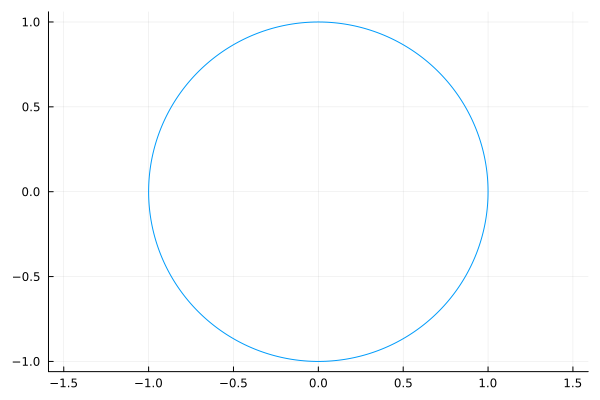

In [1]:
using Plots
t = range(0, 2π, length=1000)
plot(cos.(t), sin.(t); label=false, aspect_ratio=:equal)

**Suggerimento:** abbiamo già sostituito il comando basato sull'operatore `:` con `range`. Provate a usare `range` nei prossimi esercizi.

### Esercizio 1

Scrivere una funzione `cerchio(z, r)` che, dato un numero complesso `z` e un reale `r ≥ 0`, disegni il cerchio di centro `(real(z), imag(z))` e raggio `r`. Testare con `cerchio(1 + 2im, 2)`. A quale ascissa/ordinata arriva il cerchio?

Per poter riutilizzare la funzione nella sezione seguente, aggiungete la curva al grafico corrente con `plot!`. Per provarla da sola, create prima un grafico vuoto con `plot(aspect_ratio=:equal)`.

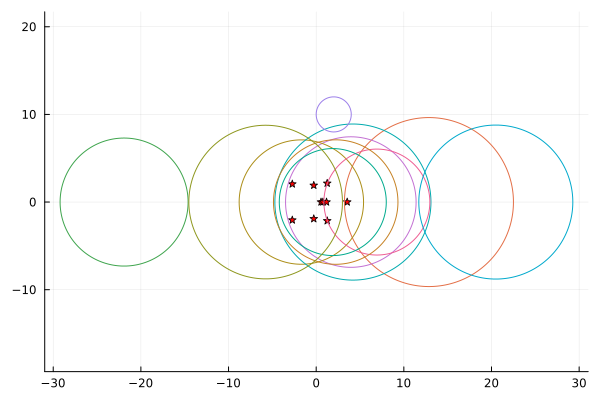

In [70]:
# Scrivete qui la funzione cerchio(z, r) e il test richiesto
function cerchio(z,r)
t = range(0, 2π, length=1000)
plot!(r.*(cos.(t) .+ real(z)), r.*(sin.(t) .+ imag(z)); label=false, aspect_ratio=:equal)
end
cerchio(1+5im,2)

## 4. Cerchi di Gerschgorin

La seguente funzione disegna gli autovalori e i cerchi di Gerschgorin di una matrice quadrata `A`. La funzione `eigvals`, fornita da `LinearAlgebra`, calcola gli autovalori. `plot!` e `scatter!` aggiungono elementi al grafico corrente.

In [50]:
function gg(A)
    n = size(A, 1)  # cosa fa questa istruzione?

    # Crea un nuovo grafico e forza la stessa scala sui due assi.
    p = plot(; aspect_ratio=:equal, legend=false)

    autovalori = eigvals(A)
    scatter!(p, real.(autovalori), imag.(autovalori);
             marker=:star5, color=:red)
    # :star5 disegna solo i punti, senza collegarli con linee.
    # Usate @doc scatter per conoscere le altre opzioni.
    for k = 1:n
        center = A[k, k]
        radius = 0.0  # accumulatore
        for j = 1:n
            if j != k
                radius = radius + abs(A[k, j])
            end
        end
        cerchio(center, radius)
    end
    return p

end

gg (generic function with 1 method)

### Esercizio 2

Testare la funzione `gg` su alcune matrici: `rand(10, 10)`, `randn(10, 10)` e la matrice di Hilbert di ordine 10, che in Julia possiamo costruire con `[1/(i+j-1) for i=1:10, j=1:10]`.

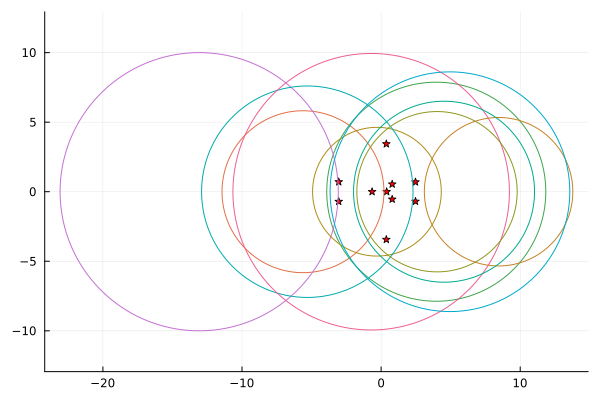

In [71]:
# Scrivete qui i test richiesti
A = randn(10,10)
gg(A)


### Esercizio 3

Scrivere una funzione `ggsecond(A)` che disegni i cerchi di Gerschgorin di $A$ e mostri come variano gli autovalori quando gli elementi fuori dalla diagonale di `A` vengono ridotti pian piano fino a diventare zero, come nella dimostrazione del secondo teorema di Gerschgorin. Per farlo, generate tante matrici (diciamo $k=100$) a intervalli uguali lungo il “segmento” che unisce $A$ alla sua diagonale e disegnate i loro autovalori.

In [61]:
# Scrivete qui la funzione ggsecond(A)
function ggsecond(A)
    n = size(A, 1)


### Esercizio 4

Nei grafici dell'esercizio precedente noterete che, per molte matrici (fate qualche esempio!), alcuni autovalori si “muovono” secondo questo schema: due autovalori reali si muovono nella stessa direzione e si avvicinano fino a coincidere; poi, una volta uniti, si staccano dall'asse reale e vanno in due direzioni opposte del piano complesso. Verificate questo fenomeno. Sapete spiegare perché accade?

In [ ]:
# Inserite qui gli esperimenti dell'esercizio 4

### Esercizio 5 (facoltativo)

Scrivete una funzione `perturb(A, epsilon)` che, data una matrice $A$, generi 50 matrici i cui elementi sono quelli di $A$ modificati con un valore casuale piccolo, di grandezza circa `epsilon`, ottenibile con le istruzioni `epsilon * (randn(n, n) + im * randn(n, n))`, e disegni i loro autovalori su un grafico.

Di quanto si spostano gli autovalori per una perturbazione di grandezza `epsilon = 1e-2`? Per una matrice casuale? Per l'identità? E per una matrice che ha un singolo blocco di Jordan di dimensione 5?

In [ ]:
# Scrivete qui la funzione perturb(A, epsilon) e i test richiesti

### Esercizio 6 (facoltativo): operazioni vettoriali e cicli

In MATLAB, soprattutto nelle versioni storiche, interpretare ogni singola istruzione aveva un costo non trascurabile. Sostituire operazioni ripetute su scalari con una singola operazione su un vettore — la cosiddetta *vectorization* — permetteva quindi spesso di velocizzare molto i programmi. Per esempio, si preferiva

```matlab
s = sum(abs(v));
```

a un ciclo esplicito con $O(n)$ istruzioni interpretate. Le versioni recenti di MATLAB hanno ridotto questa differenza grazie a un compilatore JIT.

Julia compila le funzioni JIT e i cicli sono normalmente efficienti: non è necessario vettorizzare il codice soltanto per evitare il costo dell'interprete. Le operazioni su interi array rimangono però spesso più concise. In Julia la somma precedente può essere scritta `s = sum(abs, v)`, che applica `abs` agli elementi senza creare un vettore temporaneo.

Riuscite a riscrivere i programmi della scorsa lezione, per esempio `fact` e `myexp2`, usando funzioni che operano su collezioni (`sum`, `prod`, `cumprod`, …) al posto dei cicli `for`? Confrontate chiarezza, allocazioni e tempi delle due versioni. Questa osservazione sarà utile quando affronteremo i cicli annidati per il calcolo delle fattorizzazioni matriciali nelle prossime lezioni.

In [ ]:
# Scrivete qui le versioni basate su operazioni su collezioni